In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.18.0


In [35]:
import os
print(os.listdir("C:\\DriveD\\projects\\AI_ML\\data\\DATASET\\waste\\train\\"))


['R_1.jpg', 'R_10.jpg', 'R_100.jpg', 'R_1000.jpg', 'R_1001.jpg', 'R_1002.jpg', 'R_1003.jpg', 'R_1004.jpg', 'R_1005.jpg', 'R_1006.jpg', 'R_1007.jpg', 'R_1008.jpg', 'R_1009.jpg', 'R_101.jpg', 'R_1010.jpg', 'R_1011.jpg', 'R_1012.jpg', 'R_1013.jpg', 'R_1014.jpg', 'R_1015.jpg', 'R_1016.jpg', 'R_1017.jpg', 'R_1018.jpg', 'R_1019.jpg', 'R_102.jpg', 'R_1020.jpg', 'R_1021.jpg', 'R_1022.jpg', 'R_1023.jpg', 'R_1024.jpg', 'R_1025.jpg', 'R_1026.jpg', 'R_1027.jpg', 'R_1028.jpg', 'R_1029.jpg', 'R_103.jpg', 'R_1030.jpg', 'R_1031.jpg', 'R_1032.jpg', 'R_1033.jpg', 'R_1034.jpg', 'R_1035.jpg', 'R_1036.jpg', 'R_1037.jpg', 'R_1038.jpg', 'R_1039.jpg', 'R_104.jpg', 'R_1040.jpg', 'R_1041.jpg', 'R_1042.jpg', 'R_1043.jpg', 'R_1044.jpg', 'R_1045.jpg', 'R_1046.jpg', 'R_1047.jpg', 'R_1048.jpg', 'R_1049.jpg', 'R_105.jpg', 'R_1050.jpg', 'R_1051.jpg', 'R_1052.jpg', 'R_1053.jpg', 'R_1054.jpg', 'R_1055.jpg', 'R_1056.jpg', 'R_1057.jpg', 'R_1058.jpg', 'R_1059.jpg', 'R_106.jpg', 'R_1060.jpg', 'R_1061.jpg', 'R_1062.jpg', 'R_

DATASET PREPARATION

In [ ]:

train_dir = "C:\\DriveD\\projects\\AI_ML\\data\\DATASET\\TRAIN\\"
test_dir = "C:\\DriveD\\projects\\AI_ML\\data\\DATASET\\TEST\\"
val_dir = "C:\\DriveD\\projects\\AI_ML\\data\\DATASET\\TEST\\"

val_datagen = ImageDataGenerator(rescale=1./255)

Task 1: create train generator

Found 22564 images belonging to 2 classes.


Task 2: Create test_generator

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 2513 images belonging to 2 classes.


In [43]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)


Found 2513 images belonging to 2 classes.


Task 3: Print length of train_generator

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)
print("Number of batches in train_generator:", len(train_generator))

Number of batches in train_generator: 706


MODEL CREATION


In [45]:
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False   # Feature extraction

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(train_generator.num_classes, activation="softmax")
])

# Task 4: Print summary

In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Task 5: Compile model

In [47]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# TRAINING

In [48]:
history_extract = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
706/706 ━━━━━━━━━━━━━━━━━━━━ 866s 1s/step - accuracy: 0.9086 - loss: 0.2246 - val_accuracy: 0.9192 - val_loss: 0.2238
Epoch 2/5
706/706 ━━━━━━━━━━━━━━━━━━━━ 524s 743ms/step - accuracy: 0.9552 - loss: 0.1196 - val_accuracy: 0.8822 - val_loss: 0.2747
Epoch 3/5
706/706 ━━━━━━━━━━━━━━━━━━━━ 549s 778ms/step - accuracy: 0.9678 - loss: 0.0881 - val_accuracy: 0.8631 - val_loss: 0.3713
Epoch 4/5
706/706 ━━━━━━━━━━━━━━━━━━━━ 2582s 4s/step - accuracy: 0.9776 - loss: 0.0636 - val_accuracy: 0.8922 - val_loss: 0.3061
Epoch 5/5
706/706 ━━━━━━━━━━━━━━━━━━━━ 3108s 4s/step - accuracy: 0.9846 - loss: 0.0403 - val_accuracy: 0.8735 - val_loss: 0.4084


# Fine-tuning: Unfreeze some layers

In [53]:
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="categorical_crossentropy", metrics=["accuracy"])


In [ ]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

458/706 ━━━━━━━━━━━━━━━━━━━━ 21:38 5s/step - accuracy: 0.9637 - loss: 0.1005

# PLOTS

Task 6: Accuracy curves (Extract Features Model)

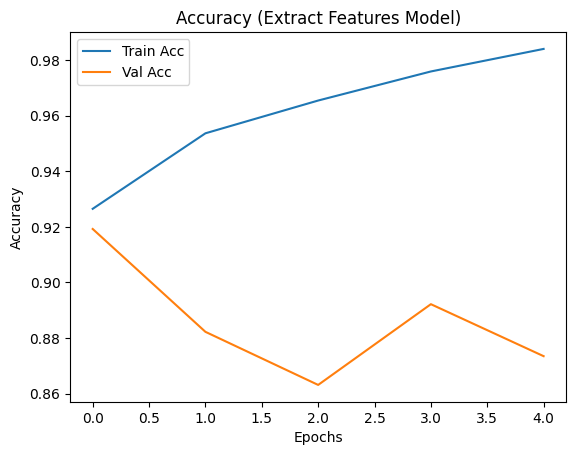

In [50]:
plt.plot(history_extract.history['accuracy'], label="Train Acc")
plt.plot(history_extract.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy (Extract Features Model)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Task 7: Loss curves (Fine Tune Model)

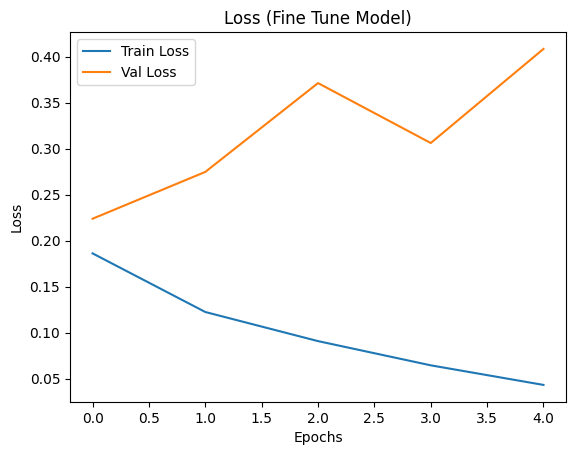

In [ ]:
plt.plot(history_finetune.history['loss'], label="Train Loss")
plt.plot(history_finetune.history['val_loss'], label="Val Loss")
plt.title("Loss (Fine Tune Model)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Task 8: Accuracy curves (Fine Tune Model)

In [ ]:
plt.plot(history_finetune.history['accuracy'], label="Train Acc")
plt.plot(history_finetune.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy (Fine Tune Model)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ----------------------
# TEST IMAGE PLOTS
# ----------------------

Task 9: Plot test image with Extract Features Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


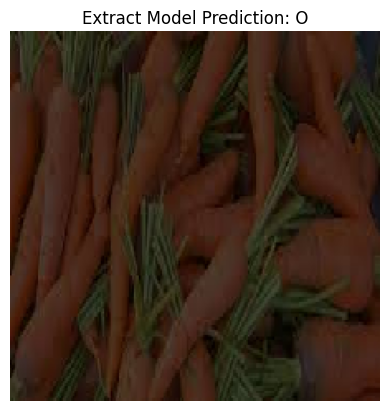

In [51]:
index_to_plot = 1
x_test, y_test = test_generator[index_to_plot]
preds_extract = model.predict(x_test)

plt.imshow(x_test[0])
plt.title("Extract Model Prediction: " + 
          list(test_generator.class_indices.keys())[np.argmax(preds_extract[0])])
plt.axis("off")
plt.show()

Task 10: Plot test image with Fine-Tuned Model

In [ ]:
preds_finetune = model.predict(x_test)

plt.imshow(x_test[0])
plt.title("Fine-Tuned Model Prediction: " + 
          list(test_generator.class_indices.keys())[np.argmax(preds_finetune[0])])
plt.axis("off")
plt.show()
